In [1]:
%load_ext autoreload
%autoreload 2

import os, sys 
sys.path.append("../models")
sys.path.append("../models/src_foley")
sys.path.append("../models/src_plotting")
from src_foley.load_all import *
from src_plotting.load_all import *
from qutip import *
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from tqdm import tqdm

100%|██████████| 300/300 [00:02<00:00, 113.38it/s]


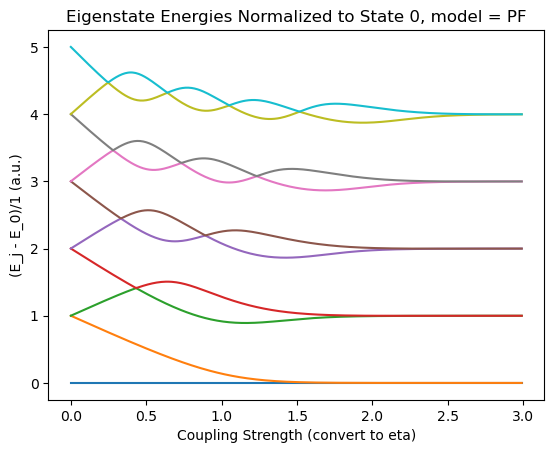

In [4]:
chain_length = 1

params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': np.array([[1, 0] * chain_length]),
    'photon_freqs': [1],
    'photon_max_nums': [100],
    'spatial': False,
    'lambdas': None,
    'mus': None,
    'positions': [],
    'model': "minus",
    'descr': "test_diff",
    'filepaths':None,
    'bases' : None
}

mini = 0
maxi = 3
step = 0.01

# using foley method model replicate figure 1

systems_1tls_minus = get_2ls_hamiltonians(params, chain_length, mini , maxi, step)

plot_energies(systems_1tls_minus, [i for i in range(10)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (convert to eta)", model="PF")

In [8]:
chain_length = 1

params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': np.array([[1, 0] * chain_length]),
    'photon_freqs': [1],
    'photon_max_nums': [100],
    'spatial': False,
    'lambdas': None,
    'mus': None,
    'positions': [],
    'model': "pzw",
    'descr': "test_diff",
    'filepaths':None,
    'bases': None
}

100%|██████████| 300/300 [00:02<00:00, 115.18it/s]


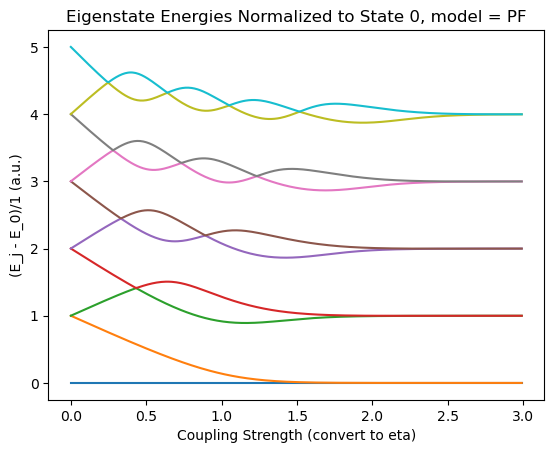

In [9]:
mini = 0
maxi = 3
step = 0.01

# using foley method model replicate figure 1

systems_1tls_pzw = get_2ls_hamiltonians(params, chain_length, mini , maxi, step)

plot_energies(systems_1tls_pzw, [i for i in range(10)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (convert to eta)", model="PF")

100%|██████████| 300/300 [00:11<00:00, 26.98it/s]


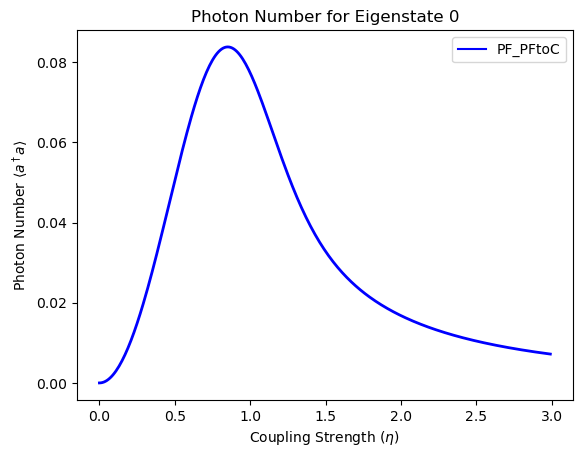

In [17]:
# plot_compare([systems_1tls_pzw], [0], mini, maxi, step, 
#                  omega = 1, norm_state=None, xlabel="", lims=[], operator="pn", models_s=["1tls_PFtoD"])
plot_compare([systems_1tls_pzw], [0], mini, maxi, step, 
                 omega = 1, norm_state=None, xlabel="Coupling Strength ($\eta$)", lims=[], operator="pn", models_s=["PF_PFtoC"])

100%|██████████| 300/300 [00:02<00:00, 114.10it/s]


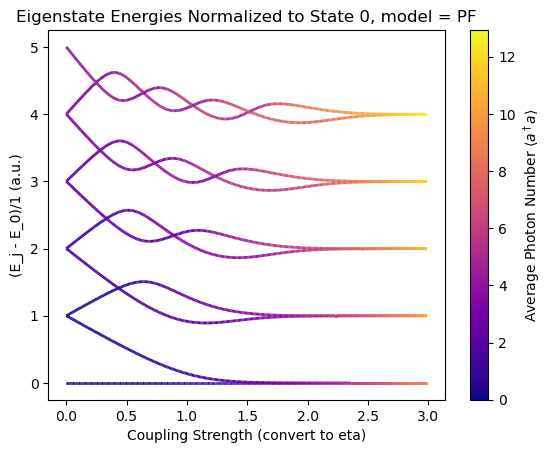

100%|██████████| 300/300 [00:02<00:00, 105.65it/s]


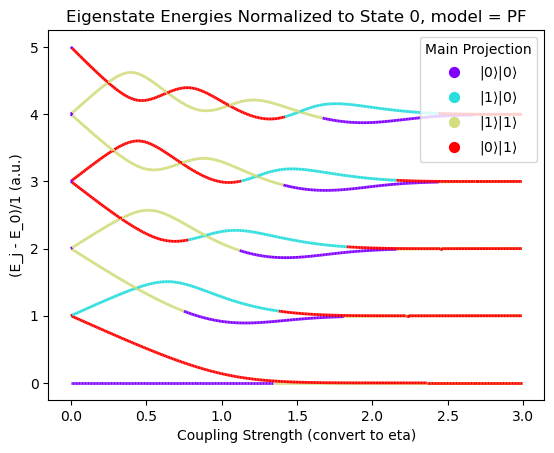

In [40]:
op_list = [[[0], [0]], [[1], [0]], [[1], [1]], [[0], [1]]]
plot_polaritons(systems_1tls_pzw, [i for i in range(10)], mini, maxi, step, 
                omega=1, norm_state = 0, 
                xlabel = "Coupling Strength (convert to eta)", model="PF", cmap='plasma')

plot_domstate(systems_1tls_pzw, [i for i in range(10)], mini, maxi, step, norm_state= 0, omega=1, op_list=op_list,
                 xlabel = "Coupling Strength (convert to eta)", model="PF", cmap='rainbow')

100%|██████████| 300/300 [00:10<00:00, 28.44it/s]


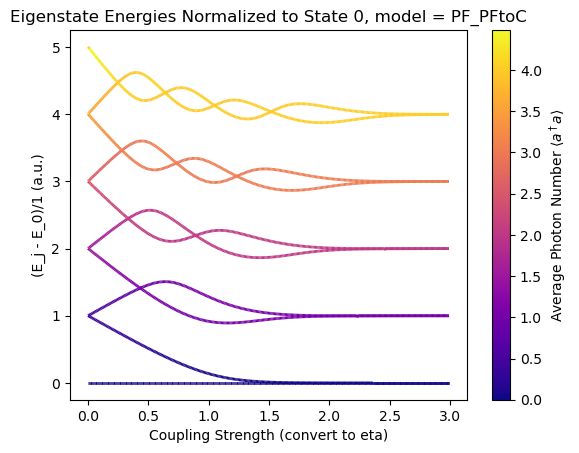

100%|██████████| 300/300 [00:12<00:00, 24.17it/s]


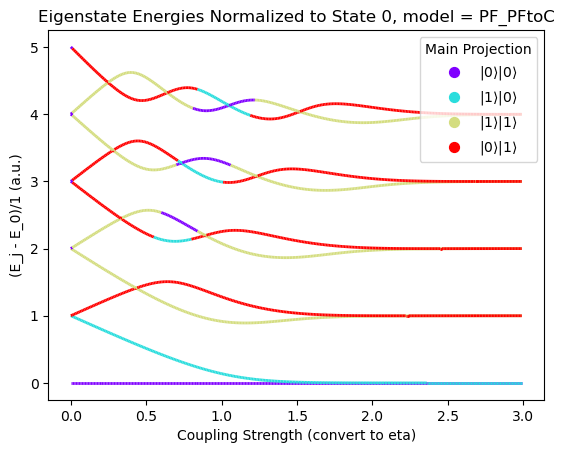

In [41]:
op_list = [[[0], [0]], [[1], [0]], [[1], [1]], [[0], [1]]]
plot_polaritons(systems_1tls_pzw, [i for i in range(10)], mini, maxi, step, 
                omega=1, norm_state = 0, 
                xlabel = "Coupling Strength (convert to eta)", model="PF_PFtoC", cmap='plasma')

plot_domstate(systems_1tls_pzw, [i for i in range(10)], mini, maxi, step, norm_state= 0, omega=1, op_list=op_list,
                 xlabel = "Coupling Strength (convert to eta)", model="PF_PFtoC", cmap='rainbow')

100%|██████████| 120/120 [00:01<00:00, 117.24it/s]


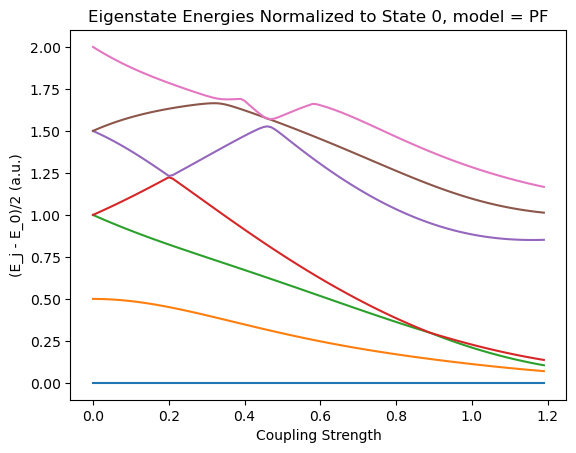

100%|██████████| 120/120 [00:01<00:00, 114.52it/s]


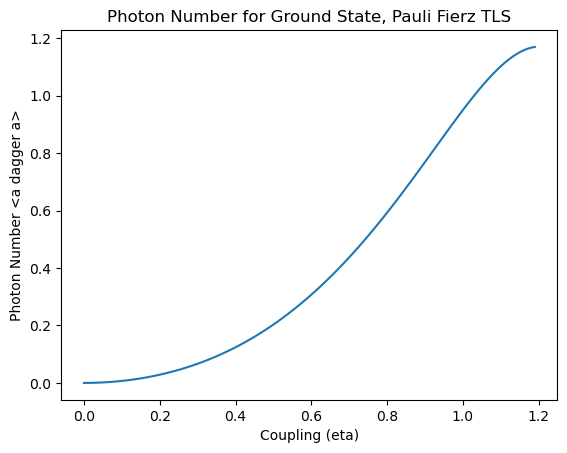

In [47]:
# Replicating figure 4 with Foley Equation

params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [2],
    'photon_max_nums': [50],
    'spatial': False,
    'couplings': None,
    'positions': [],
    'model': 'pzw',
    'descr': "",
    'mus': None,
    'filepath': None,
}

chain_length = 2
params['system_e_levels'] = np.array([[2, 0], [1, 0]])

mini = 0
maxi = 1.2
step = 0.01
eigenstates = 7

systems_pf = get_2ls_hamiltonians(params, chain_length, mini , maxi, step)
plot_energies(systems_pf, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength", model="PF")

plot_aa(systems_pf, 0, mini, maxi, step, 
        xlabel = "Coupling (eta)", title = "Photon Number for Ground State, Pauli Fierz TLS", model="PF")

100%|██████████| 120/120 [00:04<00:00, 29.34it/s]


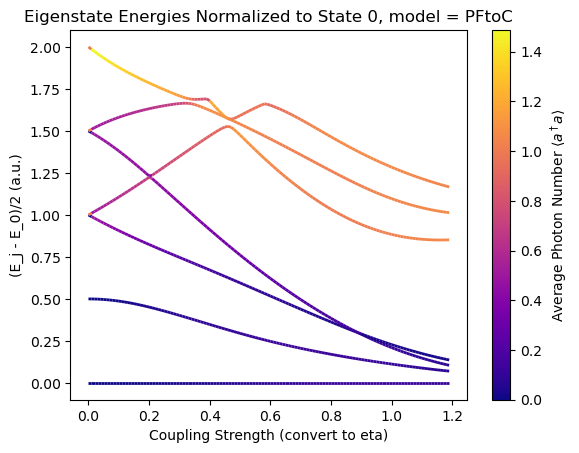

100%|██████████| 120/120 [00:08<00:00, 14.31it/s]


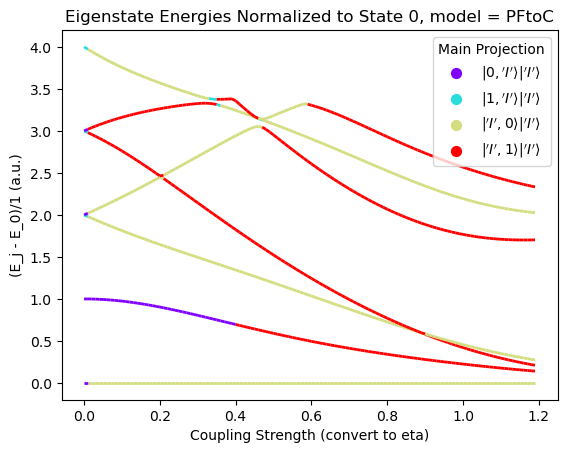

In [48]:
eigenstates = 7
plot_polaritons(systems_pf, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength (convert to eta)", model="PFtoC",
               cmap='plasma')

# comps = [[[0, 0],['I']], [[1, 0],['I']], [[0, 1],['I']], [[1, 1],['I']]]
comps = []
plot_domstate(systems_pf, [i for i in range(eigenstates)], mini, maxi, step, 
              omega=1, norm_state = 0, op_list=comps,
                 xlabel = "Coupling Strength (convert to eta)", model="PFtoC", cmap='rainbow')

In [ ]:
# state = 0
# comps = [[[0, 0],[0]], [[1, 0],[0]], [[0, 1],[0]], [[1, 1],[0]]]
# plot_state_comp(systems_pf, state, comps, mini, maxi, step, 
#                 xlabel="Coupling Strength (convert to eta)", model="2 2ls")